# 4. Model Training

*Proposal section 3.2.3.* Tunes and trains the two Random Forest classifiers, one for workers and one for clients. Saves the tuned models for `05_model_evaluation` and the Flask service.

## Setup

Runs locally or in Google Colab. In Colab it mounts Google Drive, copies this repo's code from GitHub, and points `data/` at **My Drive** (raw files in the Drive root, outputs in `My Drive/processed`) and `models/` at `My Drive/models`, so outputs survive between sessions.

In [1]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    REPO_URL = "https://github.com/JamieNguru/169421-escrow-based-wallet-and-payment-system.git"
    if not Path("/content/repo").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", "dev", REPO_URL, "/content/repo"], check=True)
    ROOT = Path("/content/repo/trust-scoring-ml")
    DRIVE = Path("/content/drive/MyDrive")
    (DRIVE / "models").mkdir(exist_ok=True)
    for name, target in [("data", DRIVE), ("models", DRIVE / "models")]:
        if not (ROOT / name).exists():
            (ROOT / name).symlink_to(target, target_is_directory=True)
else:
    ROOT = Path.cwd().parent

sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import pandas as pd
from IPython.display import Image, display

from src.model_io import save_model
from src.plots import plot_tuning_heatmap
from src.train import (
    MODEL_VERSION,
    PARAM_GRID,
    split_client_dataset,
    split_worker_dataset,
    tune_client_model,
    tune_worker_model,
)

In [3]:
worker_dataset = pd.read_csv(PROCESSED_DIR / "worker_features.csv")
client_dataset = pd.read_csv(PROCESSED_DIR / "client_features.csv")
print("Workers:", worker_dataset.shape, " Clients:", client_dataset.shape)

Workers: (592, 5)  Clients: (627, 5)


## Train/test split

Each dataset is split 80/20, keeping the Low/Medium/High mix the same in both parts. The 20% test set is not used here at all; it's held back for `05_model_evaluation`.

In [4]:
splits = {
    "worker": split_worker_dataset(worker_dataset),
    "client": split_client_dataset(client_dataset),
}
pd.DataFrame({
    f"{role} {part}": y.value_counts()
    for role, (_, _, y_train, y_test) in splits.items()
    for part, y in [("train", y_train), ("test", y_test)]
})

,worker train,worker test,client train,client test
trust_level,,,,
Low,158,40,167,42
Medium,158,39,167,42
High,157,40,167,42


## Hyperparameter tuning

The number of trees and the maximum depth are tuned with a grid search: every combination below is scored by 5-fold cross-validation on the training split (macro F1, which weights the three trust levels equally). The best combination is then refit on the whole training split.

In [5]:
PARAM_GRID

{'n_estimators': [100, 200, 400], 'max_depth': [None, 5, 10, 20]}

In [6]:
searches = {
    "worker": tune_worker_model(worker_dataset),
    "client": tune_client_model(client_dataset),
}

In [7]:
def cv_table(search):
    results = pd.DataFrame(search.cv_results_)
    return (
        results[["param_n_estimators", "param_max_depth", "mean_test_score", "std_test_score", "rank_test_score"]]
        .rename(columns=lambda c: c.replace("param_", "").replace("_test_score", "_cv_f1"))
        .sort_values("rank_cv_f1")
        .round(4)
        .reset_index(drop=True)
    )

cv_table(searches["worker"])

,n_estimators,max_depth,mean_cv_f1,std_cv_f1,rank_cv_f1
0,400,None,0.8921,0.0226,1
1,400,20,0.8921,0.0226,1
2,100,10,0.8921,0.0231,3
3,200,None,0.8918,0.0175,4
4,200,20,0.8918,0.0175,4
5,400,10,0.8901,0.0239,6
6,200,10,0.8899,0.0228,7
7,100,None,0.8858,0.0175,8
8,100,20,0.8858,0.0175,8
9,400,5,0.8836,0.0173,10


In [8]:
cv_table(searches["client"])

,n_estimators,max_depth,mean_cv_f1,std_cv_f1,rank_cv_f1
0,400,10,0.9018,0.0327,1
1,100,10,0.9017,0.0322,2
2,100,20,0.9000,0.0354,3
3,100,None,0.9000,0.0354,3
4,200,10,0.8997,0.0359,5
5,400,20,0.8982,0.0327,6
6,400,None,0.8982,0.0327,6
7,200,None,0.8940,0.0383,8
8,200,20,0.8940,0.0383,8
9,400,5,0.8732,0.0456,10


## Best settings

Compared with the untuned starting point (200 trees, no depth limit), which is one of the combinations in the grid.

In [9]:
def default_score(search):
    for params, score in zip(search.cv_results_["params"], search.cv_results_["mean_test_score"]):
        if params == {"n_estimators": 200, "max_depth": None}:
            return score

pd.DataFrame([
    {
        "model": role,
        "best n_estimators": search.best_params_["n_estimators"],
        "best max_depth": str(search.best_params_["max_depth"]),
        "best CV macro F1": round(search.best_score_, 4),
        "untuned CV macro F1": round(default_score(search), 4),
    }
    for role, search in searches.items()
]).set_index("model")

,best n_estimators,best max_depth,best CV macro F1,untuned CV macro F1
model,,,,
worker,400,None,0.8921,0.8918
client,400,10,0.9018,0.8940


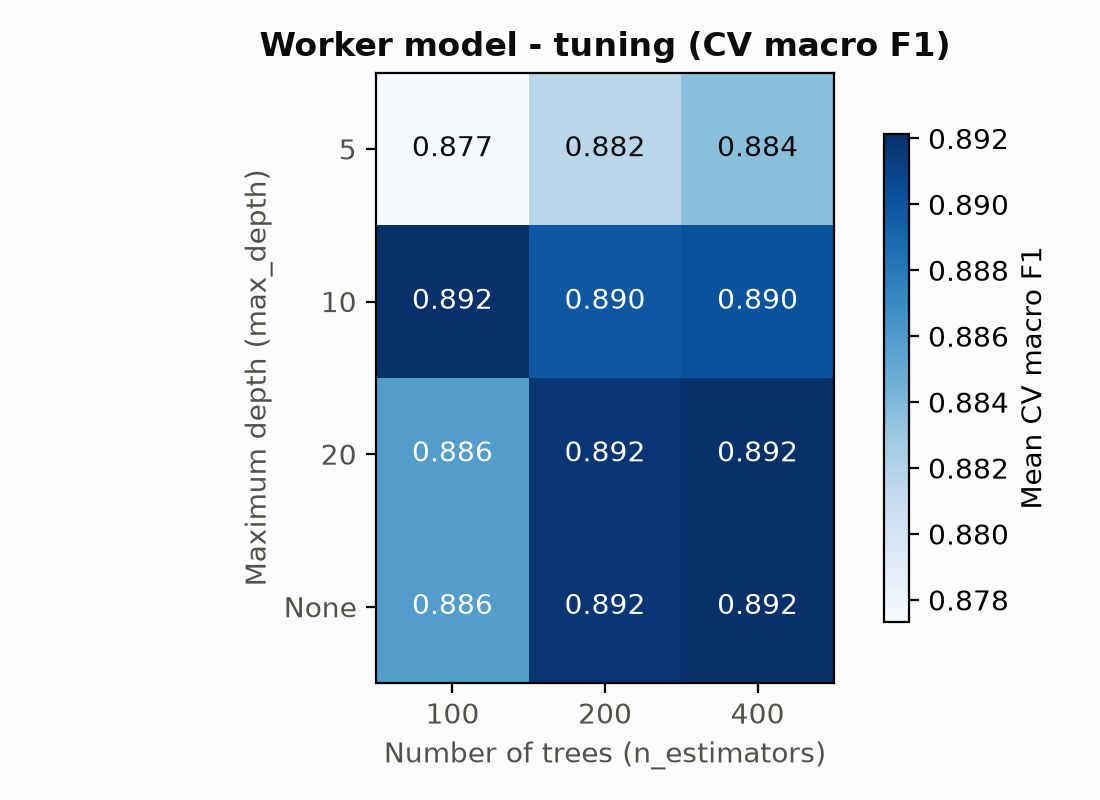

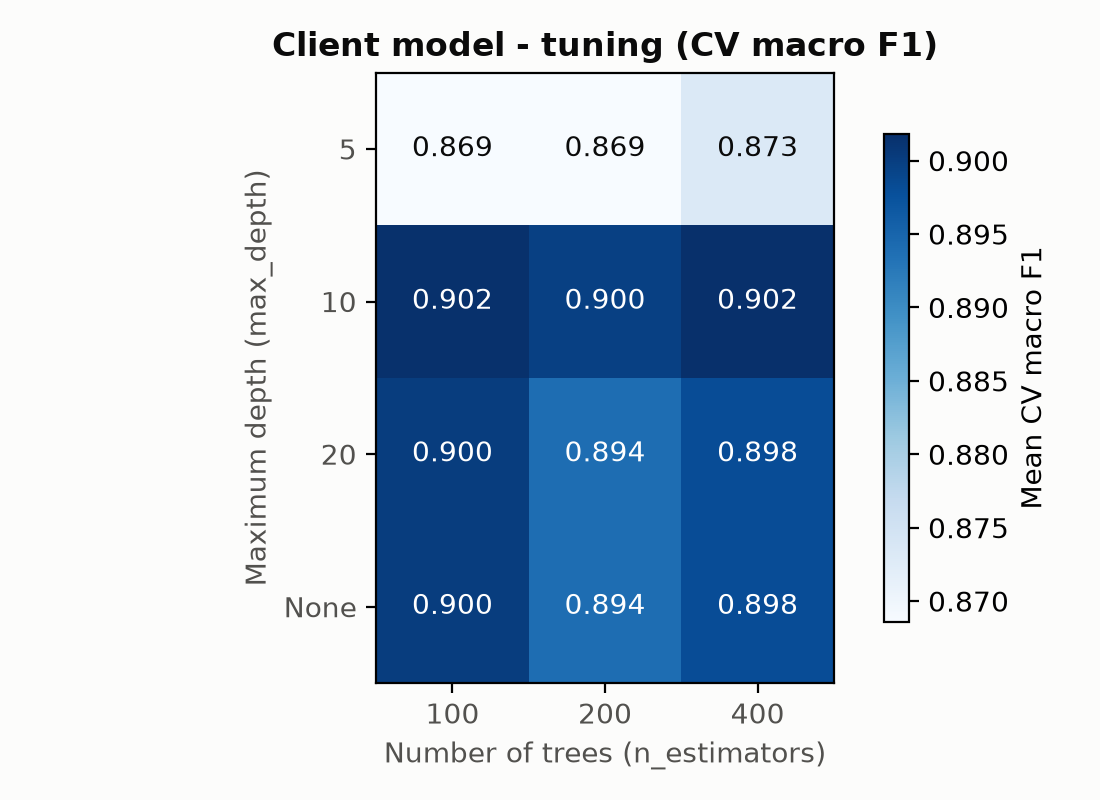

In [10]:
for role, search in searches.items():
    path = FIGURES_DIR / f"{role}_tuning_heatmap.png"
    plot_tuning_heatmap(search.cv_results_, f"{role.title()} model - tuning (CV macro F1)", path)
    display(Image(filename=str(path), width=450))

## What tuning showed

Tuning changes little. For workers, 400 trees with no depth limit scores best (CV macro F1 0.892), level with the original 200 trees (0.892). For clients, 400 trees with a maximum depth of 10 scores best (0.902, against 0.894 untuned). Both differences are smaller than the variation between folds (standard deviation 0.02-0.04). The dependable finding is the same for both models: shallow trees (`max_depth=5`) do worst.

Scores are lower than in earlier versions (around 0.94) because the trust label now genuinely depends on all three features instead of mostly one, which makes it harder to reproduce exactly.

## Save the tuned models

In [11]:
for role, search in searches.items():
    path = save_model(search.best_estimator_, role, MODEL_VERSION)
    print(f"Saved {role} model: {path.relative_to(ROOT).as_posix()}")

Saved worker model: models/worker_trust_model_v1.joblib


Saved client model: models/client_trust_model_v1.joblib
